# Regresion Lineal Multiple — ROI publicitario

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Multiple

---

### Objetivo

Construir un modelo de regresion lineal multiple que prediga las ventas a partir de la inversion en TV, Radio y Prensa.

### Contexto de negocio

**El cliente:** un director de marketing que necesita justificar su presupuesto publicitario ante el CFO.

**El problema:** se invierten miles de euros en tres canales (TV, Radio, Prensa) pero no se sabe cual genera mas retorno. El director necesita datos para reasignar presupuesto al canal mas rentable.

**La pregunta:** por cada 1.000 euros adicionales en cada canal, cuantas unidades mas se venden?

## 1️. Setup: librerías y configuración visual

In [ ]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Modelado estadístico (interpretación)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# Machine Learning (predicción)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tests estadísticos
from scipy import stats

# Configuración general
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)  # Reproducibilidad — siempre fijar la semilla

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis (1 por gráfico) / serie única en scatter y líneas
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto en un mismo gráfico
INK           = '#111111'
MUTED         = '#707070'

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

print(' Setup completado. Versiones:')
print(f'  pandas       {pd.__version__}')
print(f'  numpy        {np.__version__}')
print(f'  statsmodels  {sm.__version__}')
import sklearn; print(f'  sklearn      {sklearn.__version__}')

## 2. Carga de datos

In [2]:
data = pd.read_csv("Advertising.csv")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 200 | Columnas: 4


,TV,Radio,Newspaper,Sales
0,230.1000,37.8000,69.2000,22.1000
1,44.5000,39.3000,45.1000,10.4000
2,17.2000,45.9000,69.3000,9.3000
3,151.5000,41.3000,58.5000,18.5000
4,180.8000,10.8000,58.4000,12.9000


## 3. EDA: Análisis Exploratorio de datos

In [3]:
# Estadística descriptiva

# Seleccionamos solo las columnas numericas relevantes
cols_num = ["TV", "Radio", "Newspaper", "Sales"]
data[cols_num].describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.0000,200.0000,200.0000,200.0000
mean,147.0400,23.2600,30.5500,14.0200
std,85.8500,14.8500,21.7800,5.2200
min,0.7000,0.0000,0.3000,1.6000
25%,74.3800,9.9800,12.7500,10.3800
50%,149.7500,22.9000,25.7500,12.9000
75%,218.8200,36.5200,45.1000,17.4000
max,296.4000,49.6000,114.0000,27.0000


In [4]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
TV,float64,0,0.0000,190
Radio,float64,0,0.0000,167
Newspaper,float64,0,0.0000,172
Sales,float64,0,0.0000,121


In [ ]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["TV", "Radio", "Newspaper", "Sales"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=NEUTRAL_LINE, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlación

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=DIVERGING_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=BACKGROUND,
    cbar_kws={"shrink": 0.75},
    annot_kws={
        "size": 10,
        "weight": "bold",
    },
)
color_annotations(ax, corr.values, threshold=0.8)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Columna del target (Sales)


- ``TV``: 0.7822 → correlación fuerte y positiva. 
- ``Radio``: 0.5762 → correlación moderada y positiva.
- ``Newspaper``: 0.2283 → correlación débil y positiva. 

Entre variables predictoras
- ``TV ↔ Radio:`` 0.0548 → correlación muy débil.
- ``TV ↔ Newspaper``: 0.0566 → correlación muy débil.
- ``Radio ↔ Newspaper``: 0.3541 → correlación débil-moderada y positiva.
Conclusión

La matriz de correlación muestra que TV es el canal publicitario con mayor relación lineal con las ventas, seguido de Radio, mientras que Newspaper apenas presenta una asociación significativa. Además, las correlaciones entre las variables predictoras son bajas, lo que sugiere que no existen problemas importantes de multicolinealidad y que las tres variables podrían incorporarse conjuntamente a un modelo de regresión múltiple para evaluar su contribución individual a la predicción de las ventas

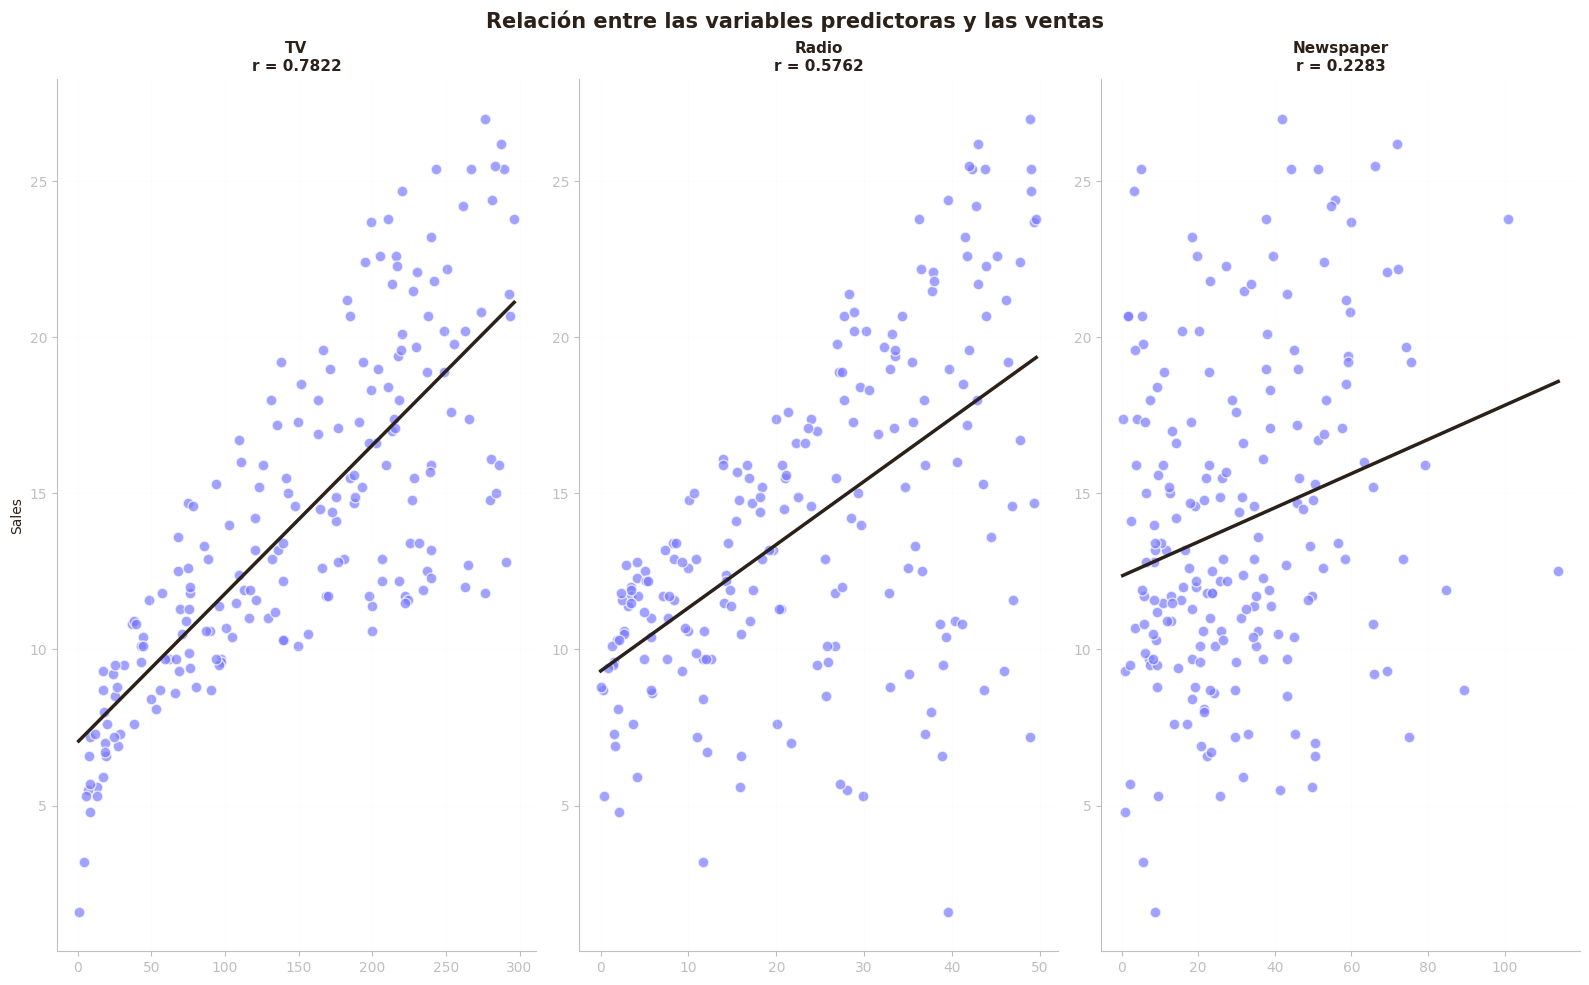

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(cols_num[:-1]):

    sns.regplot(
        data=data,
        x=col,
        y="Sales",
        ax=axes[i],
        scatter_kws={
            "color": PURPLE,
            "edgecolor": "white",
            "s": 60,
            "alpha": 0.70,
        },
        line_kws={
            "color": INK,
            "linewidth": 2.5,
        },
        ci=None,
    )

    r = data[col].corr(data["Sales"])

    axes[i].set_title(
        f"{col}\nr = {r:.4f}",
        fontsize=11,
        fontweight="bold",
        color=INK,
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Sales" if i % 3 == 0 else "")

    axes[i].grid(alpha=0.25)

plt.suptitle(
    "Relación entre las variables predictoras y las ventas",
    fontsize=15,
    fontweight="bold",
    color=INK,
)

plt.tight_layout()
plt.show()

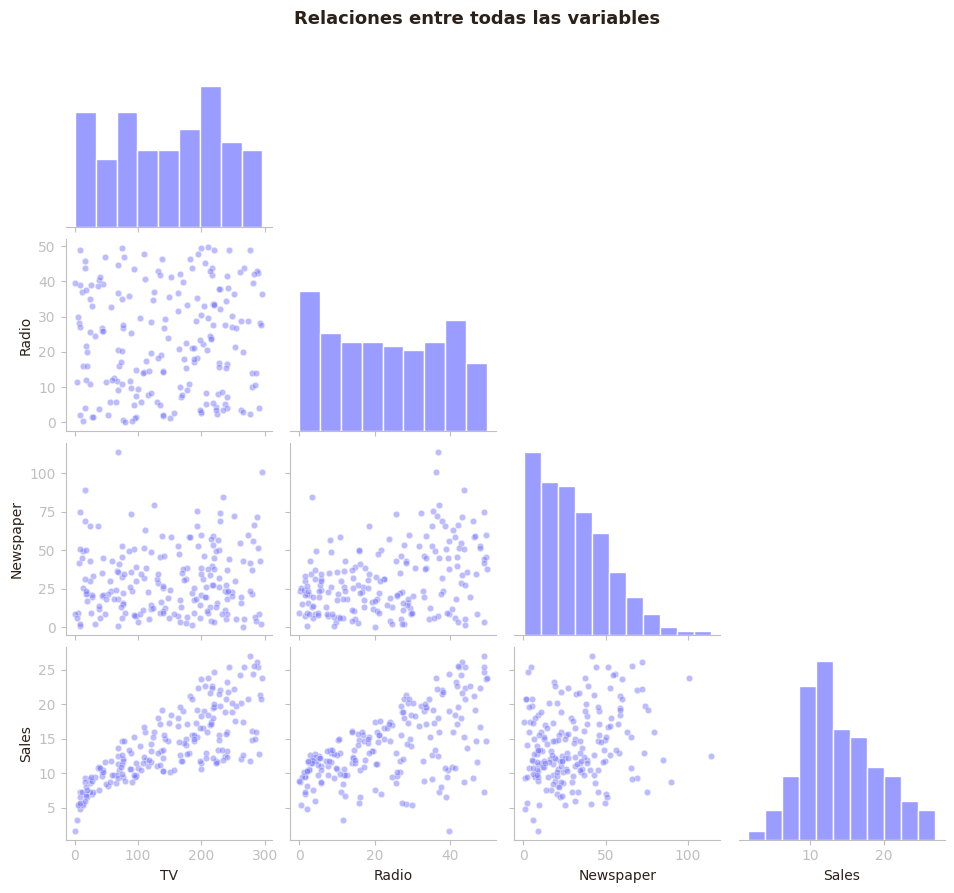

In [8]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data, height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Selección del modelo

In [9]:
# Modelo 1: Regresión Múltiple con todas variables
X = data[["TV", "Radio", "Newspaper"]]
y = data["Sales"]
X_const = sm.add_constant(X)
modelo = sm.OLS(y, X_const).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        18:49:04   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

### Conclusión
- ``TV``: es la variable con mayor capacidad explicativa sobre las ventas.
- ``Radio``: también contribuye de forma significativa al modelo.
- ``Newspaper``: con un p-valor de 0.860 no aporta información estadísticamente significativa una vez consideradas las otras dos variables.

- Por tanto, un modelo formado únicamente por TV y Radio ofrece prácticamente la misma capacidad predictiva que el modelo con las tres variables, pero con una menor complejidad y una interpretación más sencilla.

#### Comprobamos si existe multicolinealidad

In [10]:
# Calculamos VIF para el Modelo 1 (todas las variables)
def calcular_vif(X):
    """Calcula el VIF para cada predictor de X (sin constante)."""
    X_c = sm.add_constant(X)
    vif = pd.DataFrame({
        'Variable': X_c.columns,
        'VIF': [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
    })
    vif = vif[vif['Variable'] != 'const'].reset_index(drop=True)
    vif['Diagnóstico'] = vif['VIF'].apply(
        lambda v: 'OK' if v < 5 else ('Vigilar' if v < 10 else 'Grave')
    )
    return vif

print('VIF del MODELO 1 (todas variables):')
print(calcular_vif(X).to_string(index=False))

VIF del MODELO 1 (todas variables):
 Variable    VIF Diagnóstico
       TV 1.0046          OK
    Radio 1.1450          OK
Newspaper 1.1452          OK


### Modelo sin incluir Newspaper

In [11]:
# Modelo 2: Regresión Múltiple sin Newspaper
X_2 = data[["TV", "Radio"]]
X_2_const = sm.add_constant(X_2)
modelo_2 = sm.OLS(y, X_2_const).fit()

print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           4.83e-98
Time:                        18:49:04   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0

In [12]:
print('VIF del MODELO 2 (TV y Radio):')
print(calcular_vif(X_2).to_string(index=False))

VIF del MODELO 2 (TV y Radio):
Variable    VIF Diagnóstico
      TV 1.0030          OK
   Radio 1.0030          OK


In [13]:
# Resumen comparativo
print('RESUMEN DEL MODELO 2 (Regresión Múltiple — 2 variables)')
print('═' * 60)
print(f'  R²                : {modelo_2.rsquared:.6f}   ← antes: {modelo.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_2.rsquared_adj:.6f}   ← antes: {modelo.rsquared_adj:.6f}')
print(f'  AIC               : {modelo_2.aic:.2f}        ← antes: {modelo.aic:.2f}')
print(f'  Error típico (s)  : {np.sqrt(modelo_2.mse_resid):.4f}   ← antes: {np.sqrt(modelo.mse_resid):.4f}')
print()

coefs_2 = pd.DataFrame({
    'Coeficiente': modelo_2.params.round(4),
    'Error típico': modelo_2.bse.round(4),
    't': modelo_2.tvalues.round(4),
    'p-valor': modelo_2.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_2.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_2)

RESUMEN DEL MODELO 2 (Regresión Múltiple — 2 variables)
════════════════════════════════════════════════════════════
  R²                : 0.897194   ← antes: 0.897211
  R² ajustado       : 0.896151   ← antes: 0.895637
  AIC               : 778.39        ← antes: 780.36
  Error típico (s)  : 1.6814   ← antes: 1.6855

COEFICIENTES:
       Coeficiente  Error típico       t     p-valor Significativo
const       2.9211        0.2945  9.9192  4.5656e-19            Sí
TV          0.0458        0.0014 32.9087  5.4370e-82            Sí
Radio       0.1880        0.0080 23.3824  9.7770e-59            Sí


El modelo demuestra que TV y Radio son suficientes para explicar cerca del 90 % de la variabilidad de las ventas. La eliminación de Newspaper no reduce prácticamente la capacidad predictiva del modelo y, además, mejora ligeramente indicadores como el AIC y el error típico. Esto indica que la inversión en prensa no aporta información adicional relevante una vez conocida la inversión realizada en televisión y radio.

### Diagnóstico de residuos ¿es válido nuestro modelo?

In [ ]:
modelo_final = modelo_2
residuos = modelo_final.resid
predichos = modelo_final.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Diagnóstico de residuos del modelo final', fontsize=14, fontweight='bold', color=INK, y=1.00)

# 1. Residuos vs valores predichos (linealidad + homocedasticidad)
axes[0, 0].scatter(predichos, residuos, color=PURPLE, alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
axes[0, 0].axhline(0, color=INK, linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Valores predichos')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('1. Residuos vs predichos\n(busca patrones / forma de embudo)', color=INK)
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma de residuos (normalidad)
axes[0, 1].hist(residuos, bins=20, color=PURPLE, edgecolor='white', alpha=0.85, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
                color=INK, linewidth=2, label='Normal teórica')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('2. Histograma de residuos\n(comparar con curva de referencia)', color=INK)
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (normalidad)
sm.qqplot(residuos, line='45', fit=True, ax=axes[1, 0],
          markerfacecolor=PURPLE, markeredgecolor='white', alpha=0.7, markersize=6)
axes[1, 0].set_title('3. Q-Q plot\n(los puntos deben seguir la línea diagonal)', color=INK)
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuos vs orden (independencia)
axes[1, 1].scatter(range(len(residuos)), residuos, color=PURPLE, alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
axes[1, 1].axhline(0, color=INK, linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('Orden de observación')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('4. Residuos vs orden\n(no debe haber tendencia ni ciclos)', color=INK)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Validación con train/test split

In [15]:
X = data[["TV","Radio"]]
y = data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")

Train: 150 registros | Test: 50 registros


## 6. Modelo Regresión Múltiple

In [16]:
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     637.0
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           3.81e-73
Time:                        18:49:05   Log-Likelihood:                -289.26
No. Observations:                 150   AIC:                             584.5
Df Residuals:                     147   BIC:                             593.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8245      0.350      8.059      0.0

In [17]:
# Entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes
b0 = model.intercept_
b_tv, b_radio = model.coef_

print("Ecuación del modelo:")
print(f"  Sales = {b0:.2f} + {b_tv:.4f} × TV + {b_radio:.4f} × Radio")

print()
print("Interpretación:")
print(f"  - Intercepto: {b0:.2f} (ventas estimadas cuando la inversión en TV y Radio es 0).")
print(f"  - TV: cada unidad adicional invertida en televisión aumenta las ventas en {b_tv:.4f} unidades, manteniendo constante la inversión en radio.")
print(f"  - Radio: cada unidad adicional invertida en radio aumenta las ventas en {b_radio:.4f} unidades, manteniendo constante la inversión en televisión.")

Ecuación del modelo:
  Sales = 2.82 + 0.0454 × TV + 0.1928 × Radio

Interpretación:
  - Intercepto: 2.82 (ventas estimadas cuando la inversión en TV y Radio es 0).
  - TV: cada unidad adicional invertida en televisión aumenta las ventas en 0.0454 unidades, manteniendo constante la inversión en radio.
  - Radio: cada unidad adicional invertida en radio aumenta las ventas en 0.1928 unidades, manteniendo constante la inversión en televisión.


### Conclusiones

- El modelo de regresión múltiple construido con TV y Radio alcanza un R² = 0.897, por lo que explica aproximadamente el 89.7 % de la variabilidad de las ventas.
- El R² ajustado (0.895) es muy próximo al R², indicando que ambas variables aportan información relevante.
- El modelo demuestra que la inversión en televisión y radio explica cerca del 90 % de las ventas. Ambas variables tienen un efecto positivo y estadísticamente significativo, mientras que la eliminación de Newspaper simplifica el modelo sin perder capacidad predictiva.

In [18]:
# Entrenamos con sklearn
modelo_ml = LinearRegression()
modelo_ml.fit(X_train, y_train)

# Predicciones
y_pred_train = modelo_ml.predict(X_train)
y_pred_test  = modelo_ml.predict(X_test)

# Métricas
def metricas(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    print(f'{nombre}:')
    print(f'  R²    : {r2:.4f}')
    print(f'  RMSE  : {rmse:.2f}  (raíz del error cuadrático medio, ventas)')
    print(f'  MAE   : {mae:.2f}  (error absoluto medio, ventas)')
    print(f'  MAPE  : {mape:.2f}%  (error porcentual medio)')
    return r2, rmse

print('═' * 60)
r2_train, rmse_train = metricas(y_train, y_pred_train, 'TRAIN (datos vistos)')
print()
r2_test,  rmse_test  = metricas(y_test, y_pred_test, 'TEST (datos nuevos)')
print('═' * 60)

# Diagnóstico de overfitting
diff_r2 = r2_train - r2_test
print(f'\nDiferencia R²: {diff_r2:.4f}')
if abs(diff_r2) < 0.05:
    print('No hay overfitting: el modelo generaliza bien.')
elif diff_r2 > 0.05:
    print('Posible overfitting: el modelo va mejor en train que en test.')
else:
    print('Atípico: el modelo va mejor en test (poco común, revisar muestra).')

════════════════════════════════════════════════════════════
TRAIN (datos vistos):
  R²    : 0.8966
  RMSE  : 1.66  (raíz del error cuadrático medio, ventas)
  MAE   : 1.21  (error absoluto medio, ventas)
  MAPE  : 13.91%  (error porcentual medio)

TEST (datos nuevos):
  R²    : 0.8945
  RMSE  : 1.69  (raíz del error cuadrático medio, ventas)
  MAE   : 1.39  (error absoluto medio, ventas)
  MAPE  : 14.39%  (error porcentual medio)
════════════════════════════════════════════════════════════

Diferencia R²: 0.0021
No hay overfitting: el modelo generaliza bien.


El modelo muestra un buen rendimiento predictivo, explicando cerca del 90 % de la variabilidad de las ventas tanto en entrenamiento como en prueba.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
axes[0].scatter(y_test, y_pred_test, color=PURPLE, alpha=0.6, edgecolors="white", s=50)
lims = [min(y_test.min(), y_pred_test.min())-1, max(y_test.max(), y_pred_test.max())+1]
axes[0].plot(lims, lims, color=INK, linestyle="--", linewidth=1, label="Prediccion perfecta")
axes[0].set_xlabel("Ventas reales", fontsize=11)
axes[0].set_ylabel("Ventas predichas", fontsize=11)
axes[0].set_title(f"Real vs Predicho (R2={r2_test:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()

# Importancia de coeficientes
canales = list(X_train.columns)
coef_df = pd.DataFrame({"Canal": canales, "Coeficiente": model.coef_})
coef_df = coef_df.sort_values("Coeficiente", ascending=True)
colors = [POSITIVE if c > 0.01 else NEGATIVE for c in coef_df["Coeficiente"]]
axes[1].barh(coef_df["Canal"], coef_df["Coeficiente"], color=colors, edgecolor="white")
axes[1].set_xlabel("Coeficiente (impacto en ventas)", fontsize=11)
axes[1].set_title("Impacto de cada canal", fontsize=12, fontweight="bold")
axes[1].axvline(0, color=INK, linewidth=0.5)

plt.tight_layout()
plt.show()

## 7. Simulacion de escenarios — redistribucion de presupuesto

La pregunta del director de marketing: si tengo un presupuesto fijo, como lo redistribuyo?

In [20]:
# Escenario base: inversión media actual
budget_actual = data[["TV", "Radio"]].mean()

ventas_actual = modelo_ml.predict(
    budget_actual.to_frame().T
)[0]

# Escenario 1: aumentar un 20 % la inversión en TV
budget_tv = budget_actual.copy()
budget_tv["TV"] *= 1.20

ventas_tv = modelo_ml.predict(
    budget_tv.to_frame().T
)[0]

# Escenario 2: aumentar un 20 % la inversión en Radio
budget_radio = budget_actual.copy()
budget_radio["Radio"] *= 1.20

ventas_radio = modelo_ml.predict(
    budget_radio.to_frame().T
)[0]

print("SIMULACIÓN DE ESCENARIOS")
print("─" * 60)

print(f"Escenario actual")
print(f"  TV    : {budget_actual['TV']:.2f}")
print(f"  Radio : {budget_actual['Radio']:.2f}")
print(f"  Ventas estimadas: {ventas_actual:.2f}\n")

print(f"Aumentar TV un 20 %")
print(f"  Ventas estimadas: {ventas_tv:.2f} ({ventas_tv - ventas_actual:+.2f})\n")

print(f"Aumentar Radio un 20 %")
print(f"  Ventas estimadas: {ventas_radio:.2f} ({ventas_radio - ventas_actual:+.2f})\n")

mejor = "TV" if ventas_tv > ventas_radio else "Radio"

print(f"Recomendación: si solo puede incrementarse un canal, el modelo estima un mayor impacto aumentando la inversión en {mejor}.")

SIMULACIÓN DE ESCENARIOS
────────────────────────────────────────────────────────────
Escenario actual
  TV    : 147.04
  Radio : 23.26
  Ventas estimadas: 13.99

Aumentar TV un 20 %
  Ventas estimadas: 15.33 (+1.34)

Aumentar Radio un 20 %
  Ventas estimadas: 14.89 (+0.90)

Recomendación: si solo puede incrementarse un canal, el modelo estima un mayor impacto aumentando la inversión en TV.


## 8. Insights de negocio y recomendaciones

El modelo desarrollado es capaz de predecir las **ventas** con un **89.7 % de capacidad explicativa (R² = 0.897)** utilizando únicamente dos variables: la inversión en **Televisión (TV)** y **Radio**.

- **¿Qué ha aprendido el modelo?**

Manteniendo constante la inversión en radio:

- Cada unidad adicional invertida en **TV** incrementa las ventas en **0.0454 unidades**.

Manteniendo constante la inversión en televisión:

- Cada unidad adicional invertida en **Radio** incrementa las ventas en **0.1928 unidades**.

Ambas variables son altamente significativas (**p < 0.001**), lo que confirma que la inversión en estos dos canales tiene una influencia positiva sobre las ventas.

- **¿Por qué se eligió este modelo?**

Aunque inicialmente se evaluó un modelo con **TV, Radio y Newspaper**, la variable **Newspaper** no resultó estadísticamente significativa y no aportaba información adicional una vez conocida la inversión en televisión y radio.


### Recomendaciones de negocio

- Priorizar la inversión publicitaria en **Televisión** y **Radio**, ya que son los canales con mayor capacidad para explicar el comportamiento de las ventas.
- Revisar la estrategia de inversión en **Prensa (Newspaper)**, puesto que no aporta un efecto significativo dentro del modelo y su presupuesto podría redistribuirse hacia canales más rentables.
